# Installing Packages

In [1]:
import pandas as pd

# Importing data

In [243]:
df_orders = pd.read_csv('../data/raw/orders.csv')

print(df_orders.columns)
print(df_orders.shape)
df_orders.head()

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='str')
(3421083, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [244]:
# Reading data
df_orders_products_train = pd.read_csv('../data/raw/order_products_train.csv')
print(df_orders_products_train.columns)
print(df_orders_products_train.shape)
df_orders_products_train.head()

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='str')
(1384617, 4)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [245]:
df_products = pd.read_csv("../data/raw/products.csv")
df_products.head()

,product_id,product_name,aisle_id,department_id,prices
0,1,Chocolate Sandwich Cookies,61,19,5.8
1,2,All-Seasons Salt,104,13,9.3
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5
4,5,Green Chile Anytime Sauce,5,13,4.3


In [246]:
df_departments = pd.read_csv('../data/processed/departments_t.csv')
print(df_departments.columns)
print(df_departments.shape)
df_departments.head()

Index(['department_id', 'department'], dtype='str')
(21, 2)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [247]:
df_aisles = pd.read_csv('../data/raw/aisles.csv')
print(df_aisles.columns)
print(df_aisles.shape)
df_aisles.head()

Index(['aisle_id', 'aisle'], dtype='str')
(134, 2)


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


# Working with Orders

In [248]:
df_orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


In [249]:
df_orders.isna().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [250]:
df_orders["order_id"].nunique()

3421083

In [251]:
if df_orders['order_id'].nunique() == df_orders.shape[0]:
    print('Happy')
else:
    print('Sad')

Happy


In [252]:
df_orders["user_id"].nunique()

206209

In [253]:
df_orders['order_id'].nunique() / df_orders["user_id"].nunique()

16.590367054784224

In [254]:
df_orders['eval_set'].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

In [255]:
df_dow = df_orders['order_dow'].value_counts().reset_index()

In [256]:
df_dow.sort_values('order_dow')

,order_dow,count
0,0,600905
1,1,587478
2,2,467260
5,3,436972
6,4,426339
3,5,453368
4,6,448761


In [257]:
df_dow.to_csv('../data/processed/dow.csv', index=False)

In [258]:
df_ohod = df_orders['order_hour_of_day'].value_counts().reset_index().sort_values('order_hour_of_day')
df_ohod.head()

,order_hour_of_day,count
18,0,22758
19,1,12398
21,2,7539
23,3,5474
22,4,5527


In [259]:
df_ohod.to_excel('../data/processed/ohod.xlsx', index = False)

In [260]:
df_orders.loc[df_orders["order_number"] == 1, "days_since_prior_order"].isna().all()

np.True_

In [261]:
needed_columns = ['days_since_prior_order','order_number','user_id']

In [262]:
df_orders[needed_columns][df_orders['order_number'] == 1].head()

,days_since_prior_order,order_number,user_id
0,NaN,1,1
11,NaN,1,2
26,NaN,1,3
39,NaN,1,4
45,NaN,1,5


In [263]:
df_first_orders = df_orders[needed_columns][df_orders['order_number'] == 1].reset_index()
df_first_orders = df_first_orders.drop(columns='index')

In [264]:
df_first_orders.head()

,days_since_prior_order,order_number,user_id
0,NaN,1,1
1,NaN,1,2
2,NaN,1,3
3,NaN,1,4
4,NaN,1,5


In [265]:
df_orders["order_id"].is_unique

True

In [266]:
df_orders["order_dow"].between(0, 6).all()

np.True_

In [267]:
df_orders_train = df_orders[df_orders["eval_set"] == "train"]
df_orders_train.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,train,11,4,8,14.0
25,1492625,2,train,15,1,11,30.0
49,2196797,5,train,5,0,11,6.0
74,525192,7,train,21,2,11,6.0
78,880375,8,train,4,1,14,10.0


In [268]:
df_orders_train.shape

(131209, 7)

In [269]:
## Since, the further analysis is going to be done based on the subset where eval_set == 'Train'
del df_orders

In [270]:
df_orders_products_train["reordered"].isin([0, 1]).all()

np.True_

In [271]:
df_orders_products_train["reordered"].value_counts(normalize=True)

reordered
1    0.598594
0    0.401406
Name: proportion, dtype: float64

In [272]:
df_orders_products_train["add_to_cart_order"].describe()

count    1.384617e+06
mean     8.758044e+00
std      7.423936e+00
min      1.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.200000e+01
max      8.000000e+01
Name: add_to_cart_order, dtype: float64

In [273]:
df_orders_products_train["order_id"].is_unique

False

In [274]:
df_orders_products_train["product_id"].is_unique

False

In [275]:
df_orders_products_train[df_orders_products_train["order_id"] == 1]

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
5,1,13176,6,0
6,1,47209,7,0
7,1,22035,8,1


In [276]:
df_products.sort_values(by = 'prices', ascending=False).head(1)

,product_id,product_name,aisle_id,department_id,prices
33666,33664,2 % Reduced Fat Milk,84,16,99999.0


In [277]:
df_products.isna().sum()

product_id        0
product_name     16
aisle_id          0
department_id     0
prices            0
dtype: int64

In [278]:
df_products["product_id"].nunique()

49686

In [279]:
df_departments.head(21)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [280]:
df_aisles.head(134)
df_aisles.shape

(134, 2)

In [281]:
df_aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [282]:
df_products.head()

,product_id,product_name,aisle_id,department_id,prices
0,1,Chocolate Sandwich Cookies,61,19,5.8
1,2,All-Seasons Salt,104,13,9.3
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5
4,5,Green Chile Anytime Sauce,5,13,4.3


In [283]:
df_products_aisles = pd.merge(df_products, df_aisles, on = "aisle_id", how = "left")

In [284]:
df_products_aisles.head()

,product_id,product_name,aisle_id,department_id,prices,aisle
0,1,Chocolate Sandwich Cookies,61,19,5.8,cookies cakes
1,2,All-Seasons Salt,104,13,9.3,spices seasonings
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen meals
4,5,Green Chile Anytime Sauce,5,13,4.3,marinades meat preparation


In [285]:
df_products_aisles_department = pd.merge(df_products_aisles, df_departments, on = 'department_id', how = 'left')

In [286]:
df_products_aisles_department.head()

,product_id,product_name,aisle_id,department_id,prices,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,5.8,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,9.3,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,4.3,marinades meat preparation,pantry


In [287]:
df_products_aisles_department.drop(columns = ['aisle_id', 'department_id'], inplace=True)

In [288]:
df_products_aisles_department.head()

,product_id,product_name,prices,aisle,department
0,1,Chocolate Sandwich Cookies,5.8,cookies cakes,snacks
1,2,All-Seasons Salt,9.3,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,4.5,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,10.5,frozen meals,frozen
4,5,Green Chile Anytime Sauce,4.3,marinades meat preparation,pantry


In [289]:
df_products_aisles_department['department'].value_counts()

department
personal care      6565
snacks             6264
pantry             5371
beverages          4365
frozen             4007
dairy eggs         3449
household          3085
canned goods       2092
dry goods pasta    1858
produce            1684
bakery             1516
deli               1322
missing            1258
international      1139
breakfast          1116
babies             1081
alcohol            1056
pets                972
meat seafood        907
other               548
bulk                 38
Name: count, dtype: int64

In [290]:
df_products_departments = pd.merge(
    df_products,
    df_departments,
    on="department_id",
    how="left"
)

df_products_departments.head()


,product_id,product_name,aisle_id,department_id,prices,department
0,1,Chocolate Sandwich Cookies,61,19,5.8,snacks
1,2,All-Seasons Salt,104,13,9.3,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen
4,5,Green Chile Anytime Sauce,5,13,4.3,pantry


In [291]:
df_products_departments_check = pd.merge(
    df_products,
    df_departments,
    on="department_id",
    how="left",
    indicator=True
)

df_products_departments_check.head()

,product_id,product_name,aisle_id,department_id,prices,department,_merge
0,1,Chocolate Sandwich Cookies,61,19,5.8,snacks,both
1,2,All-Seasons Salt,104,13,9.3,pantry,both
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,beverages,both
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen,both
4,5,Green Chile Anytime Sauce,5,13,4.3,pantry,both


In [292]:
df_products_departments_check["_merge"].value_counts()


_merge
both          49693
left_only         0
right_only        0
Name: count, dtype: int64

In [293]:
df_products_departments_check[
    df_products_departments_check["_merge"] == "left_only"
].head()

,product_id,product_name,aisle_id,department_id,prices,department,_merge


In [294]:
df_products_departments = pd.merge(
    df_products,
    df_departments,
    on="department_id",
    how="left"
)

df_products_departments.head()

,product_id,product_name,aisle_id,department_id,prices,department
0,1,Chocolate Sandwich Cookies,61,19,5.8,snacks
1,2,All-Seasons Salt,104,13,9.3,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen
4,5,Green Chile Anytime Sauce,5,13,4.3,pantry


In [295]:
df_products_departments["department"].value_counts()

department
personal care      6565
snacks             6264
pantry             5371
beverages          4365
frozen             4007
dairy eggs         3449
household          3085
canned goods       2092
dry goods pasta    1858
produce            1684
bakery             1516
deli               1322
missing            1258
international      1139
breakfast          1116
babies             1081
alcohol            1056
pets                972
meat seafood        907
other               548
bulk                 38
Name: count, dtype: int64

In [296]:
df_products_enriched = pd.merge(
    df_products_departments,
    df_aisles,
    on="aisle_id",
    how="left"
)

df_products_enriched.head()

,product_id,product_name,aisle_id,department_id,prices,department,aisle
0,1,Chocolate Sandwich Cookies,61,19,5.8,snacks,cookies cakes
1,2,All-Seasons Salt,104,13,9.3,pantry,spices seasonings
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,beverages,tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen,frozen meals
4,5,Green Chile Anytime Sauce,5,13,4.3,pantry,marinades meat preparation


In [297]:
df_products_aisles_check = pd.merge(
    df_products_departments,
    df_aisles,
    on="aisle_id",
    how="left",
    indicator=True
)

df_products_aisles_check["_merge"].value_counts()

_merge
both          49693
left_only         0
right_only        0
Name: count, dtype: int64

In [298]:
df_products_aisles_check[
    df_products_aisles_check["_merge"] == "left_only"
].head()

,product_id,product_name,aisle_id,department_id,prices,department,aisle,_merge


In [299]:
print(df_products.shape)
print(df_products_departments.shape)
print(df_products_enriched.shape)

(49693, 5)
(49693, 6)
(49693, 7)


In [300]:
df_departments["department_id"].is_unique

True

In [301]:
df_aisles["aisle_id"].is_unique

True

In [302]:
df_products_enriched["aisle"].value_counts().head(10)

aisle
missing                 1258
candy chocolate         1246
ice cream ice           1091
vitamins supplements    1038
yogurt                  1026
chips pretzels           989
tea                      894
packaged cheese          891
frozen meals             880
cookies cakes            874
Name: count, dtype: int64

In [303]:
pd.crosstab(
    df_products_enriched["department"],
    df_products_enriched["aisle"]
)

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
department,,,,,,,,,,,,,,,,,,,,,
alcohol,0,0,0,0,0,0,0,0,0,387,...,0,0,0,0,0,0,0,0,147,0
babies,0,0,44,132,718,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
bakery,0,0,0,0,0,297,0,0,0,0,...,0,0,0,241,0,0,0,0,0,0
beverages,0,0,0,0,0,0,0,0,0,0,...,0,894,0,0,0,0,0,344,0,0
breakfast,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
bulk,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
canned goods,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dairy eggs,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1026
deli,0,0,0,0,0,0,0,0,0,0,...,0,0,159,0,0,0,0,0,0,0


In [304]:
pd.merge(
    df_products,
    df_departments,
    on="department_id",
    how="inner", 
).head()

,product_id,product_name,aisle_id,department_id,prices,department
0,1,Chocolate Sandwich Cookies,61,19,5.8,snacks
1,2,All-Seasons Salt,104,13,9.3,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen
4,5,Green Chile Anytime Sauce,5,13,4.3,pantry


In [305]:
pd.merge(
    df_products,
    df_departments,
    on="department_id",
    how="left"
).head()

,product_id,product_name,aisle_id,department_id,prices,department
0,1,Chocolate Sandwich Cookies,61,19,5.8,snacks
1,2,All-Seasons Salt,104,13,9.3,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen
4,5,Green Chile Anytime Sauce,5,13,4.3,pantry


In [306]:
pd.merge(
    df_products,
    df_departments,
    on="department_id",
    how="outer",
    indicator=True
).head()

,product_id,product_name,aisle_id,department_id,prices,department,_merge
0,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5,frozen,both
1,8,Cut Russet Potatoes Steam N' Mash,116,1,1.1,frozen,both
2,12,Chocolate Fudge Layer Cake,119,1,9.4,frozen,both
3,18,Pizza for One Suprema Frozen Pizza,79,1,10.6,frozen,both
4,30,"Three Cheese Ziti, Marinara with Meatballs",38,1,13.8,frozen,both


In [307]:
df_train_transactions = pd.merge(
    df_orders_train,
    df_orders_products_train,
    on="order_id",
    how="left"
)

df_train_transactions.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,1187899,1,train,11,4,8,14.0,196,1,1
1,1187899,1,train,11,4,8,14.0,25133,2,1
2,1187899,1,train,11,4,8,14.0,38928,3,1
3,1187899,1,train,11,4,8,14.0,26405,4,1
4,1187899,1,train,11,4,8,14.0,39657,5,1


In [308]:
df_train_transactions_check = pd.merge(
    df_orders_train,
    df_orders_products_train,
    on="order_id",
    how="left",
    indicator=True
)

df_train_transactions_check.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge
0,1187899,1,train,11,4,8,14.0,196,1,1,both
1,1187899,1,train,11,4,8,14.0,25133,2,1,both
2,1187899,1,train,11,4,8,14.0,38928,3,1,both
3,1187899,1,train,11,4,8,14.0,26405,4,1,both
4,1187899,1,train,11,4,8,14.0,39657,5,1,both


In [309]:
df_train_transactions_check["_merge"].value_counts()

_merge
both          1384617
left_only           0
right_only          0
Name: count, dtype: int64

In [310]:
df_train_transactions_check[
    df_train_transactions_check["_merge"] == "left_only"
].head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge


In [311]:
print(df_orders_train.shape)
print(df_orders_products_train.shape)
print(df_train_transactions.shape)

(131209, 7)
(1384617, 4)
(1384617, 10)


In [312]:
df_train_transactions.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered'],
      dtype='str')

In [313]:
df_train_transactions.groupby("order_id").size().head()

order_id
1      8
36     8
38     9
96     7
98    49
dtype: int64

In [314]:
df_train_transactions.groupby("order_id").size().describe()

count    131209.000000
mean         10.552759
std           7.932847
min           1.000000
25%           5.000000
50%           9.000000
75%          14.000000
max          80.000000
dtype: float64

In [315]:
df_train_transactions.groupby("order_dow").size() / df_train_transactions["order_id"].nunique()

order_dow
0    2.469541
1    1.569847
2    1.223712
3    1.176604
4    1.184987
5    1.348307
6    1.579762
dtype: float64

In [316]:
df_train_transactions.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered'],
      dtype='str')

In [317]:
URL_CUSTOMERS = 'https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/raw/customers.csv'
URL_STATES = 'https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/raw/states.csv'

In [318]:
df_customers.to_csv('../data/raw/customers.csv')


In [319]:
URLS = {
    'customers_csv': URL_CUSTOMERS,
    'states_csv': URL_STATES}


In [320]:
for i in URLS.items():
    print(f'file name {i[0]} \n file path {i[1]}')

file name customers_csv 
 file path https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/raw/customers.csv
file name states_csv 
 file path https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/raw/states.csv


In [321]:
for i in URLS.items():
   print(f'Downloading {i[0]}')
   df = pd.read_csv(i[1])
   df.to_csv(f'../data/raw/{i[0]}')
   print(f'saving {i[0]} in ../data/raw')
print('The job is done')


saving customers_csv in ../data/raw
saving states_csv in ../data/raw
The job is done


In [322]:
df_customers = pd.read_csv(URL_CUSTOMERS)
df_customers.shape

(206209, 10)

In [323]:
df_customers.head()

,user_id,First Name,Surnam,Gender,STATE,Age,date_joined,n_dependants,fam_status,income
0,26711,Deborah,Esquivel,Female,Missouri,48,1/1/2017,3,married,165665
1,33890,Patricia,Hart,Female,New Mexico,36,1/1/2017,0,single,59285
2,65803,Kenneth,Farley,Male,Idaho,35,1/1/2017,2,married,99568
3,125935,Michelle,Hicks,Female,Iowa,40,1/1/2017,0,single,42049
4,130797,Ann,Gilmore,Female,Maryland,26,1/1/2017,1,married,40374


In [324]:
df_customers.to_csv('../data/raw/customers.csv')

In [325]:
df_products_enriched.to_csv('../data/processed/products_enriched.csv')


In [326]:
df_train_transactions = pd.merge(
    df_orders_train,
    df_orders_products_train,
    on = "order_id",
    how = "left",
    indicator=True
)

In [327]:
df_train_transactions.head()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge
0,1187899,1,train,11,4,8,14.0,196,1,1,both
1,1187899,1,train,11,4,8,14.0,25133,2,1,both
2,1187899,1,train,11,4,8,14.0,38928,3,1,both
3,1187899,1,train,11,4,8,14.0,26405,4,1,both
4,1187899,1,train,11,4,8,14.0,39657,5,1,both


In [328]:
df_train_transactions["_merge"].value_counts()

_merge
both          1384617
left_only           0
right_only          0
Name: count, dtype: int64

In [329]:
print(df_orders_train.shape)
print(df_orders_products_train.shape)
print(df_train_transactions.shape)

(131209, 7)
(1384617, 4)
(1384617, 11)


In [330]:
df_train_transactions.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', '_merge'],
      dtype='str')

In [331]:
df_train_analytic = pd.merge(
    df_train_transactions,
    df_products_enriched,
    on = "product_id",
    how = "left"
)

In [332]:
df_train_analytic.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge,product_name,aisle_id,department_id,prices,department,aisle
0,1187899,1,train,11,4,8,14.0,196,1,1,both,Soda,77.0,7.0,9.0,beverages,soft drinks
1,1187899,1,train,11,4,8,14.0,25133,2,1,both,Organic String Cheese,21.0,16.0,8.6,dairy eggs,packaged cheese
2,1187899,1,train,11,4,8,14.0,38928,3,1,both,0% Greek Strained Yogurt,120.0,16.0,12.6,dairy eggs,yogurt
3,1187899,1,train,11,4,8,14.0,26405,4,1,both,XL Pick-A-Size Paper Towel Rolls,54.0,17.0,1.0,household,paper goods
4,1187899,1,train,11,4,8,14.0,39657,5,1,both,Milk Chocolate Almonds,45.0,19.0,6.8,snacks,candy chocolate


In [333]:
df_train_analytic.to_csv('../data/processed/train_analytic_csv')

In [334]:
df_train_analytic.drop('eval_set', axis = 1, inplace=True)

In [335]:
df_train_analytic.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge,product_name,aisle_id,department_id,prices,department,aisle
0,1187899,1,11,4,8,14.0,196,1,1,both,Soda,77.0,7.0,9.0,beverages,soft drinks
1,1187899,1,11,4,8,14.0,25133,2,1,both,Organic String Cheese,21.0,16.0,8.6,dairy eggs,packaged cheese
2,1187899,1,11,4,8,14.0,38928,3,1,both,0% Greek Strained Yogurt,120.0,16.0,12.6,dairy eggs,yogurt
3,1187899,1,11,4,8,14.0,26405,4,1,both,XL Pick-A-Size Paper Towel Rolls,54.0,17.0,1.0,household,paper goods
4,1187899,1,11,4,8,14.0,39657,5,1,both,Milk Chocolate Almonds,45.0,19.0,6.8,snacks,candy chocolate


In [336]:
df_train_analytic.drop('_merge', axis = 1, inplace=True)

In [355]:
df_final_table = pd.merge(
    df_train_analytic,
    df_customers,
    on = "user_id",
    how = "left"
)

In [354]:
df_customers = pd.read_csv('../data/raw/customers.csv')
print(df_customers.columns)
print(df_customers.shape)
df_customers.head()


Index(['Unnamed: 0', 'user_id', 'First Name', 'Surnam', 'Gender', 'state',
       'Age', 'date_joined', 'n_dependants', 'fam_status', 'income'],
      dtype='str')
(206209, 11)


,Unnamed: 0,user_id,First Name,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income
0,0,26711,Deborah,Esquivel,Female,Missouri,48,1/1/2017,3,married,165665
1,1,33890,Patricia,Hart,Female,New Mexico,36,1/1/2017,0,single,59285
2,2,65803,Kenneth,Farley,Male,Idaho,35,1/1/2017,2,married,99568
3,3,125935,Michelle,Hicks,Female,Iowa,40,1/1/2017,0,single,42049
4,4,130797,Ann,Gilmore,Female,Maryland,26,1/1/2017,1,married,40374


In [356]:
df_final_table.head()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,Unnamed: 0,First Name,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income
0,1187899,1,11,4,8,14.0,196,1,1,Soda,...,134862,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
1,1187899,1,11,4,8,14.0,25133,2,1,Organic String Cheese,...,134862,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
2,1187899,1,11,4,8,14.0,38928,3,1,0% Greek Strained Yogurt,...,134862,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
3,1187899,1,11,4,8,14.0,26405,4,1,XL Pick-A-Size Paper Towel Rolls,...,134862,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
4,1187899,1,11,4,8,14.0,39657,5,1,Milk Chocolate Almonds,...,134862,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423


In [357]:
df_train_analytic1 = pd.merge(
    df_final_table,
    df_states, 
    on = "state",
    how = "left"
)

In [358]:
df_states.head()


,Unnamed: 0,state,region,division
0,0,Connecticut,Northeast,New England
1,1,Maine,Northeast,New England
2,2,Massachusetts,Northeast,New England
3,3,New Hampshire,Northeast,New England
4,4,Rhode Island,Northeast,New England


In [359]:
df_states = pd.read_csv('../data/raw/states.csv')
print(df_states.columns)
print(df_states.shape)
df_states.head()

Index(['Unnamed: 0', 'state', 'region', 'division'], dtype='str')
(51, 4)


,Unnamed: 0,state,region,division
0,0,Connecticut,Northeast,New England
1,1,Maine,Northeast,New England
2,2,Massachusetts,Northeast,New England
3,3,New Hampshire,Northeast,New England
4,4,Rhode Island,Northeast,New England


In [360]:
df_train_analytic1.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,Gender,state,Age,date_joined,n_dependants,fam_status,income,Unnamed: 0_y,region,division
0,1187899,1,11,4,8,14.0,196,1,1,Soda,...,Female,Alabama,31,2/17/2019,3,married,40423,30,South,East South Central
1,1187899,1,11,4,8,14.0,25133,2,1,Organic String Cheese,...,Female,Alabama,31,2/17/2019,3,married,40423,30,South,East South Central
2,1187899,1,11,4,8,14.0,38928,3,1,0% Greek Strained Yogurt,...,Female,Alabama,31,2/17/2019,3,married,40423,30,South,East South Central
3,1187899,1,11,4,8,14.0,26405,4,1,XL Pick-A-Size Paper Towel Rolls,...,Female,Alabama,31,2/17/2019,3,married,40423,30,South,East South Central
4,1187899,1,11,4,8,14.0,39657,5,1,Milk Chocolate Almonds,...,Female,Alabama,31,2/17/2019,3,married,40423,30,South,East South Central


In [361]:
df_train_analytic1.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'product_name', 'aisle_id', 'department_id', 'prices',
       'department', 'aisle', 'Unnamed: 0_x', 'First Name', 'Surnam', 'Gender',
       'state', 'Age', 'date_joined', 'n_dependants', 'fam_status', 'income',
       'Unnamed: 0_y', 'region', 'division'],
      dtype='str')

In [367]:
df_train_analytic1.drop('Unnamed: 0_x', axis = 1, inplace=True)

In [363]:
df_train_analytic1.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'product_name', 'aisle_id', 'department_id', 'prices',
       'department', 'aisle', 'Unnamed: 0_x', 'First Name', 'Surnam', 'Gender',
       'state', 'Age', 'date_joined', 'n_dependants', 'fam_status', 'income',
       'region', 'division'],
      dtype='str')

In [368]:
df_train_analytic1.to_csv('../data/processed/train_analytic.csv')


In [365]:
df_train_analytic.shape

(1384706, 15)

In [ ]:
import pandas as pd
df_instacart = pd.read_csv('../data/processed/instacart.csv')

print(df_instacart.columns)
print(df_instacart_final.shape)
df_instacart.head()




Index(['Unnamed: 0', 'order_id', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order',
       'reordered', 'product_name', 'prices', 'department', 'aisle',
       'First Name', 'Surnam', 'Gender', 'state', 'Age', 'date_joined',
       'n_dependants', 'fam_status', 'income', 'region', 'division'],
      dtype='str')
(1384706, 23)


,Unnamed: 0,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,0,1187899,11,4,8,14.0,1,1,Soda,9.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [6]:
df_train_analytic.columns

Index(['Unnamed: 0', 'order_id', 'user_id', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'department', 'aisle', 'First Name',
       'Surnam', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='str')

In [7]:
df_train_analytic.drop(columns=['user_id','product_id', 'aisle_id', 'department_id'],inplace=True)

In [8]:
df_train_analytic.columns

Index(['Unnamed: 0', 'order_id', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order',
       'reordered', 'product_name', 'prices', 'department', 'aisle',
       'First Name', 'Surnam', 'Gender', 'state', 'Age', 'date_joined',
       'n_dependants', 'fam_status', 'income', 'region', 'division'],
      dtype='str')

In [9]:
df_train_analytic.to_csv('../data/processed/train_analytics_final.csv')

NameError: name 'df_train_analytic_final' is not defined

In [27]:
print(df_train_analytics_final.shape)
df_train_analytics_final.head()


(1384706, 22)


,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [3]:
df_train_analytics_final.to_csv("../data/processed/instacart.csv", index = False)




In [9]:
import pyarrow
print(pyarrow.__version__)

23.0.1


In [10]:
import sys
print(sys.executable)

c:\Users\enovo\miniconda3\envs\myenv\python.exe


In [15]:
df_train_analytics_final.head()

,Unnamed: 0,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,0,1187899,11,4,8,14.0,1,1,Soda,9.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [6]:
df_instacart = pd.read_csv('../data/processed/instacart.csv')

print(df_instacart.columns)
print(df_instacart.shape)
df_instacart.head()



Index(['Unnamed: 0', 'order_id', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order',
       'reordered', 'product_name', 'prices', 'department', 'aisle',
       'First Name', 'Surnam', 'Gender', 'state', 'Age', 'date_joined',
       'n_dependants', 'fam_status', 'income', 'region', 'division'],
      dtype='str')
(1384706, 23)


,Unnamed: 0,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,0,1187899,11,4,8,14.0,1,1,Soda,9.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [7]:
df_instacart.drop('Unnamed: 0', axis = 1, inplace=True)


In [8]:
df_instacart.to_csv('../data/processed/instacart.csv')


In [9]:
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name', 'Surnam',
       'Gender', 'state', 'Age', 'date_joined', 'n_dependants', 'fam_status',
       'income', 'region', 'division'],
      dtype='str')

In [14]:
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [15]:
df_instacart.shape

(1384706, 22)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

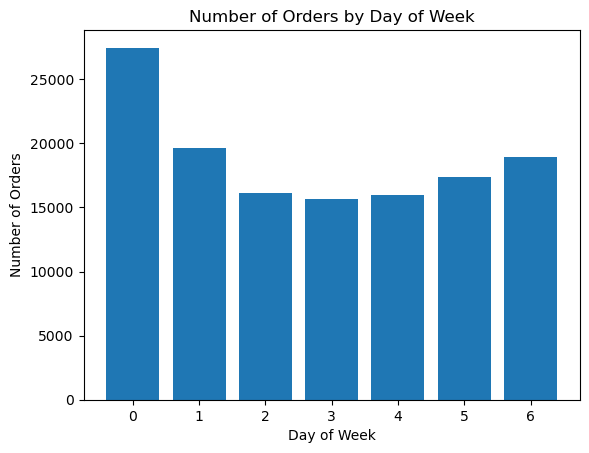

In [13]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby("order_dow")
    .size()
)

plt.figure()
plt.bar(orders_by_day.index, orders_by_day.values)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()

In [11]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby("order_dow")
    .size()
)

orders_by_day

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

In [12]:
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


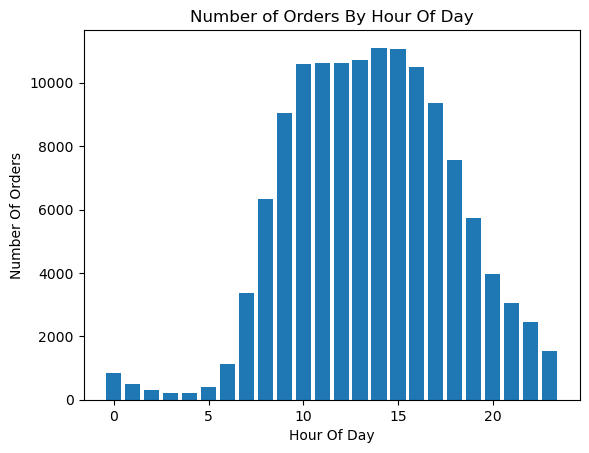

In [16]:
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)


plt.figure()
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title("Number of Orders By Hour Of Day")
plt.xlabel("Hour Of Day")
plt.ylabel("Number Of Orders")
plt.show()



In [19]:
top_departments = df_instacart["department"].value_counts().head(10)
top_departments

department
produce            409087
dairy eggs         217051
snacks             118862
beverages          113962
frozen             100426
pantry              81242
bakery              48394
canned goods        46799
deli                44291
dry goods pasta     38713
Name: count, dtype: int64

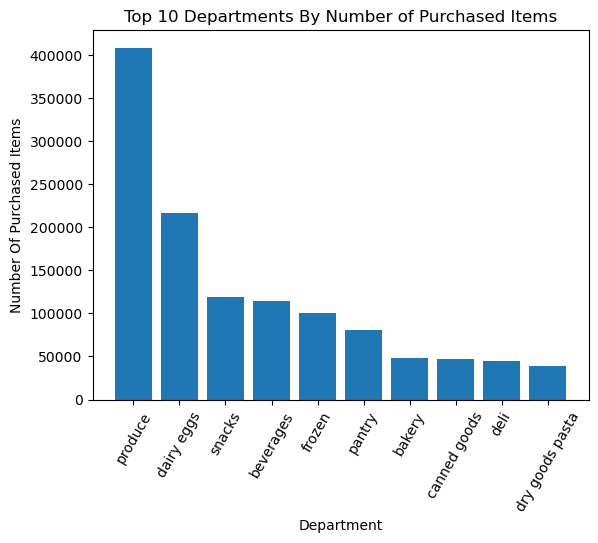

In [30]:
top_departments = df_instacart["department"].value_counts().head(10)
plt.figure()
plt.bar(top_departments.index, top_departments.values)
plt.title("Top 10 Departments By Number of Purchased Items")
plt.xlabel("Department")
plt.ylabel("Number Of Purchased Items")
plt.xticks(rotation = 60)
plt.show()

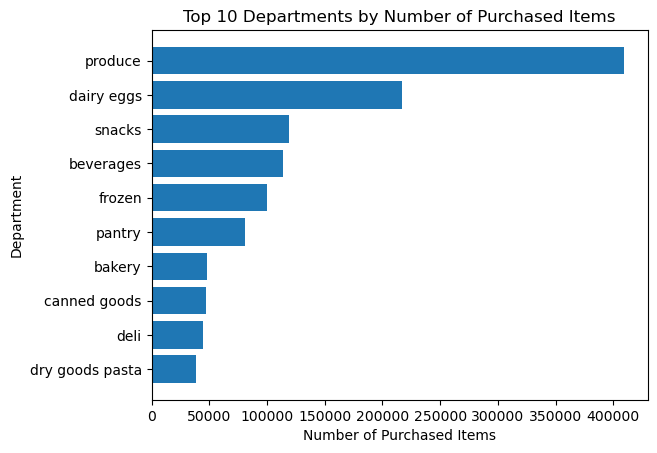

In [31]:
top_departments_sorted = df_instacart["department"].value_counts().head(10).sort_values()

plt.figure()
plt.barh(top_departments_sorted.index, top_departments_sorted.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Department")
plt.show()


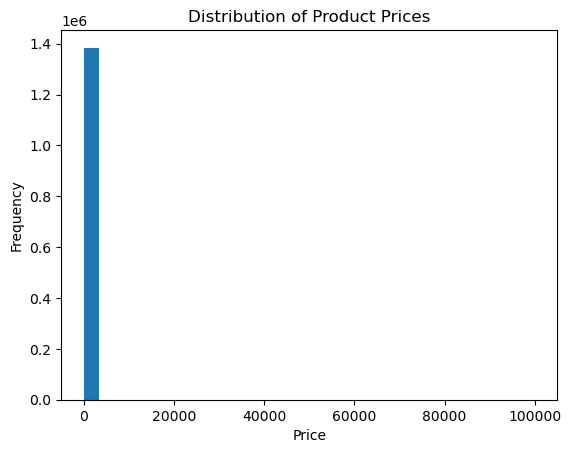

In [39]:
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [40]:
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

avg_price_by_department

department
snacks              4.272277
other               7.184457
dry goods pasta     7.388252
household           7.402065
canned goods        7.530263
beverages           7.660526
babies              7.682672
deli                7.768707
international       7.799126
frozen              7.801781
bakery              7.833023
pets                7.867823
pantry              7.955316
personal care       7.989259
produce             7.997862
breakfast           8.090261
alcohol             8.126044
bulk                8.211626
missing             8.599139
meat seafood       16.202349
dairy eggs         48.606962
Name: prices, dtype: float64

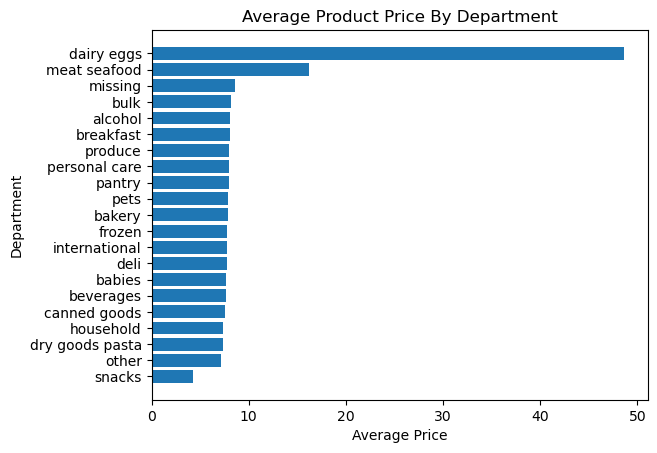

In [44]:
avg_price_by_department = (df_instacart
.groupby("department")["prices"]
.mean()
.sort_values(ascending=True)
 )


plt.figure()
plt.barh(avg_price_by_department.index, avg_price_by_department.values)
plt.title("Average Product Price By Department")
plt.xlabel("Average Price")
plt.ylabel("Department")
plt.show()

In [45]:
customer_profile = df_instacart[
    ["First Name", "Surnam", "Age", "income"]
].drop_duplicates()

customer_profile.head()

,First Name,Surnam,Age,income
0,Linda,Nguyen,31,40423
11,Norma,Chapman,68,64940
42,Janet,Lester,75,115242
51,Peter,Villegas,39,89095
60,Anna,Allison,32,88603


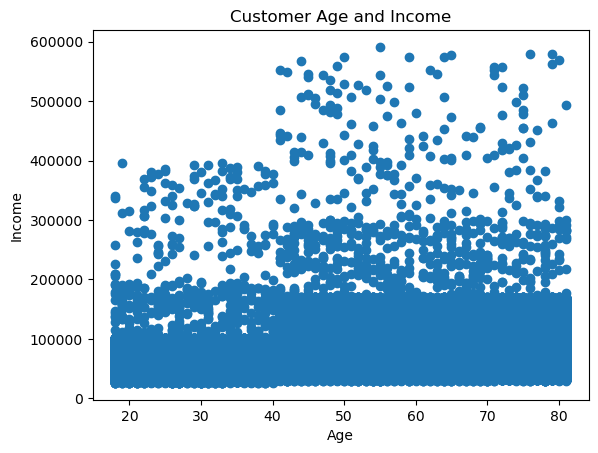

In [46]:
customer_profile = df_instacart[
    ["First Name", "Surnam", "Age", "income"]
].drop_duplicates()

plt.figure()
plt.scatter(customer_profile["Age"], customer_profile["income"])
plt.title("Customer Age and Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

In [47]:
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name', 'Surnam',
       'Gender', 'state', 'Age', 'date_joined', 'n_dependants', 'fam_status',
       'income', 'region', 'division'],
      dtype='str')